# Gradient Descent, SGD, and Momentum

This notebook reproduces every experiment in Lecture 05:

1. the cost of one step, exact solve against gradient;
2. the four learning-rate regimes on a one-dimensional quadratic;
3. gradient descent on a simulated design with a chosen condition number;
4. minibatch gradients and their noise;
5. heavy-ball momentum and the $\sqrt{\kappa}$ speedup;
6. proximal gradient and soft thresholding for the lasso.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 26510
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## The simulated design

Simulation lets us set the condition number exactly, which is the quantity the
whole lecture is about. Eigenvalues are spread geometrically from 1 down to
$1/\kappa$, then rotated so that no single feature is the bad direction.

In [2]:
def simulate(n, d, kappa, noise=.5, seed=0):
    gen = np.random.default_rng(seed)
    eigs = np.logspace(0, -np.log10(kappa), d)
    angle = np.pi/4
    rot = (np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
           if d == 2 else np.linalg.qr(gen.standard_normal((d, d)))[0])
    root = rot @ np.diag(np.sqrt(eigs)) @ rot.T
    Xs = gen.standard_normal((n, d)) @ root
    theta = np.array([1.4, -0.9]) if d == 2 else gen.standard_normal(d)
    return Xs, Xs@theta + noise*gen.standard_normal(n)

X, y = simulate(2000, 2, 8.0, seed=SEED)
H = X.T@X/len(X)
theta_star = np.linalg.solve(H, X.T@y/len(X))
print('realized condition number:', round(np.linalg.cond(H), 2))
print('Hessian eigenvalues:', np.linalg.eigvalsh(H).round(4))
print('largest stable step 2/lambda_max:', round(2/np.linalg.eigvalsh(H).max(), 3))

realized condition number: 7.67
Hessian eigenvalues: [0.1261 0.9668]
largest stable step 2/lambda_max: 2.069


## 1. The cost of one step

The exact solve is $O(nd^2+d^3)$, a full gradient is $O(nd)$, and a minibatch
gradient is $O(|B|d)$. Laptop timings are noisy, so the slide plots operation
counts and quotes one measured point --- reproduced here.

In [3]:
def _timed(fn):
    t0 = time.perf_counter(); fn(); return time.perf_counter()-t0

def best_of(fn, reps=5):
    return min(_timed(fn) for _ in range(reps))*1000

n_cost, d_cost = 20_000, 2000
Xc = np.random.default_rng(1).standard_normal((n_cost, d_cost))
yc = np.random.default_rng(2).standard_normal(n_cost)
th = np.zeros(d_cost)

print('exact solve      %8.1f ms' % best_of(lambda: np.linalg.solve(Xc.T@Xc, Xc.T@yc)))
print('full gradient    %8.1f ms' % best_of(lambda: Xc.T@(Xc@th-yc)/n_cost))
print('minibatch (128)  %8.2f ms' % best_of(lambda: Xc[:128].T@(Xc[:128]@th-yc[:128])/128))

exact solve        3393.2 ms


full gradient        79.5 ms
minibatch (128)      0.10 ms


## 2. Four learning rates on $f(x)=x^2$

Here $f''=2$, so an iterate contracts by $|1-2\eta|$: monotone for
$\eta\le 1/2$, oscillating but convergent for $1/2<\eta<1$, divergent above 1.

,eta,contraction |1-2eta|,|x| after 10 steps
0,0.05,0.9,3.486784
1,0.20,0.6,0.060466
2,0.75,0.5,0.009766
3,1.10,1.2,61.917364


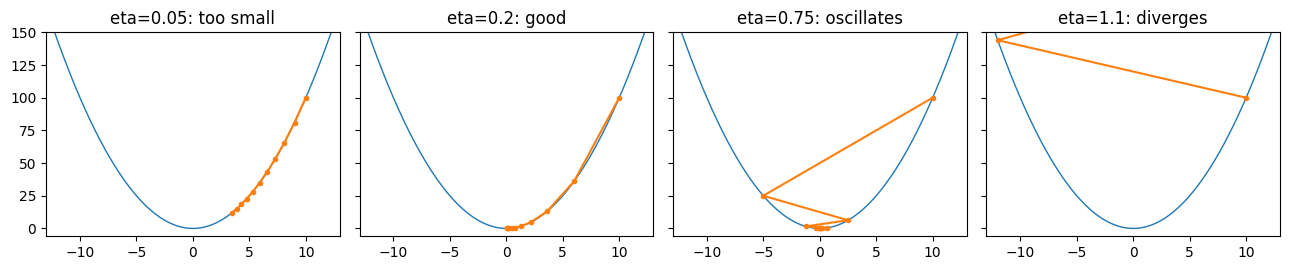

In [4]:
def descend_1d(eta, steps=10, x0=10.):
    x, path = x0, [x0]
    for _ in range(steps):
        x = x - eta*2*x
        path.append(x)
    return np.array(path)

rates = [.05, .2, .75, 1.1]
labels = ['too small', 'good', 'oscillates', 'diverges']
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharey=True)
grid = np.linspace(-13, 13, 400)
for ax, eta, label in zip(axes, rates, labels):
    p = descend_1d(eta)
    ax.plot(grid, grid**2, lw=1)
    ax.plot(p, p**2, 'o-', ms=3)
    ax.set(title=f'eta={eta}: {label}', ylim=(-6, 150), xlim=(-13, 13))
plt.tight_layout()

pd.DataFrame({'eta': rates,
              'contraction |1-2eta|': [abs(1-2*e) for e in rates],
              '|x| after 10 steps': [abs(descend_1d(e)[-1]) for e in rates]})

## 3. Gradient descent on the simulated objective

In [5]:
def loss(theta):
    return .5*np.mean((X@theta-y)**2)

def gradient(theta, indices=None):
    Xb, yb = (X, y) if indices is None else (X[indices], y[indices])
    return Xb.T@(Xb@theta-yb)/len(Xb)

def optimize(kind='gd', eta=.2, steps=100, batch_size=20, beta=.9, start=(-2., 2.4)):
    theta = np.array(start, dtype=float)
    velocity = np.zeros_like(theta)
    history = []
    for step in range(steps):
        g = gradient(theta) if kind == 'gd' else gradient(theta, rng.choice(len(X), batch_size, replace=False))
        velocity = beta*velocity + g if kind == 'momentum' else g
        theta = theta - eta*velocity
        history.append((step, loss(theta), *theta, np.linalg.norm(g)))
    return theta, pd.DataFrame(history, columns=['step','loss','theta1','theta2','grad_norm'])

theta_gd, gd = optimize('gd', eta=1.0, steps=300)
print('gradient descent:', theta_gd.round(4))
print('closed form:     ', theta_star.round(4))
assert np.allclose(theta_gd, theta_star, atol=1e-3)

gradient descent: [ 1.4028 -0.8942]
closed form:      [ 1.4028 -0.8942]


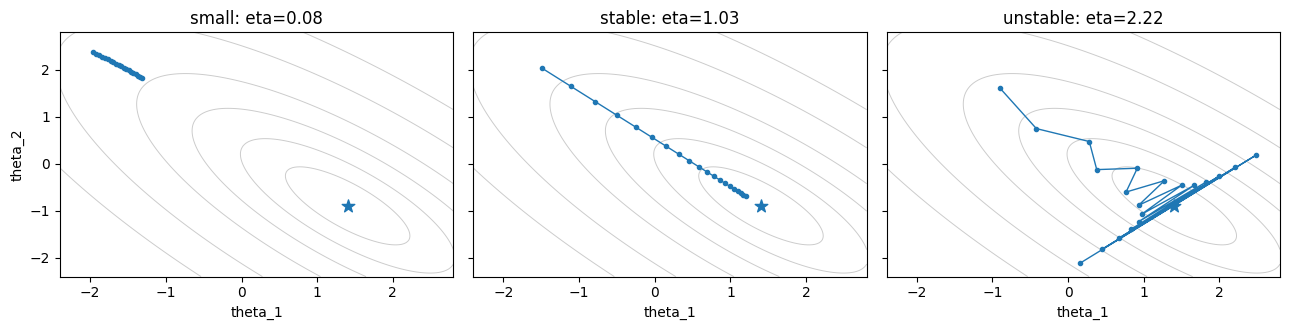

In [6]:
lmax = np.linalg.eigvalsh(H).max()
t1, t2 = np.meshgrid(np.linspace(-2.4, 2.8, 160), np.linspace(-2.4, 2.8, 160))
flat = np.column_stack([t1.ravel(), t2.ravel()])
surface = (.5*np.mean((X@flat.T - y[:, None])**2, axis=0)).reshape(t1.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True, sharey=True)
for ax, scale, name in zip(axes, [.08, 1.0, 2.15], ['small','stable','unstable']):
    eta = scale/lmax
    _, path = optimize('gd', eta=eta, steps=20)
    ax.contour(t1, t2, surface, levels=[.2,.35,.6,1.,1.8,3.], colors='0.8', linewidths=.7)
    ax.plot(path.theta1, path.theta2, 'o-', ms=3, lw=1)
    ax.scatter(*theta_star, marker='*', s=90, zorder=5)
    ax.set(title=f'{name}: eta={eta:.2f}', xlabel='theta_1')
axes[0].set_ylabel('theta_2'); plt.tight_layout();

## 4. Minibatch gradients and their noise

A minibatch gradient is unbiased for the full gradient, and its RMS error falls
like $1/\sqrt{B}$.

In [7]:
theta_probe = np.array([-.8, 1.2])
full = gradient(theta_probe)
rows = []
for B in [1,2,4,8,16,32,64,128]:
    est = np.array([gradient(theta_probe, rng.choice(len(X), B, replace=False)) for _ in range(500)])
    rows.append((B, np.linalg.norm(est.mean(0)-full), np.sqrt(np.mean(np.sum((est-full)**2, axis=1)))))
noise = pd.DataFrame(rows, columns=['batch_size','bias_of_mean','RMS_error'])
noise['sqrt_reference'] = noise.RMS_error.iloc[0]/np.sqrt(noise.batch_size)
noise.round(4)

,batch_size,bias_of_mean,RMS_error,sqrt_reference
0,1,0.0279,1.2474,1.2474
1,2,0.0058,0.9595,0.8820
2,4,0.0317,0.6913,0.6237
3,8,0.0057,0.4662,0.4410
4,16,0.0254,0.3357,0.3118
5,32,0.0162,0.2300,0.2205
6,64,0.0059,0.1669,0.1559
7,128,0.0016,0.1183,0.1103


## 5. Heavy-ball momentum

On a quadratic, Polyak's parameters contract by
$(\sqrt\kappa-1)/(\sqrt\kappa+1)$ per step instead of
$(\kappa-1)/(\kappa+1)$: the $\sqrt\kappa$ speedup. Both paths oscillate, so
only the error decay separates them.

GD : eta=0.0198                   rate/step=0.9802
HB : eta=0.0331  beta=0.669   rate/step=0.8182


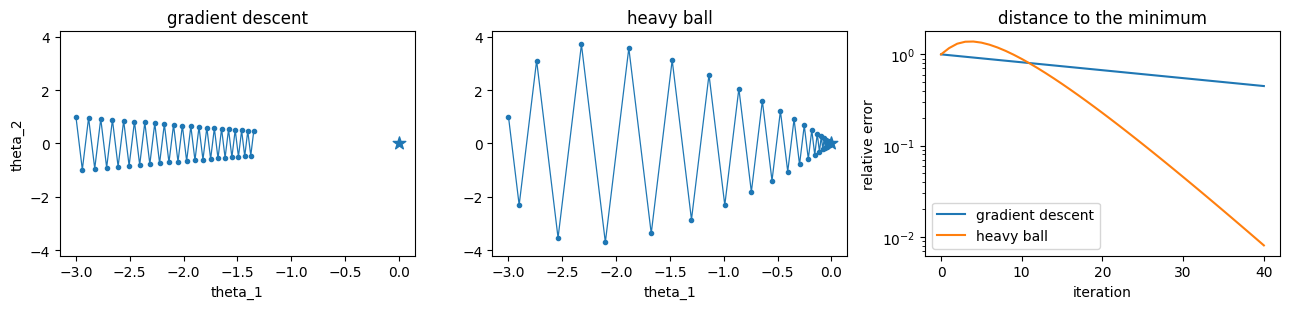

In [8]:
A = np.diag([1., 100.])
M, m = 100., 1.
kap = M/m
eta_gd = 2/(M+m)
beta_hb = ((np.sqrt(kap)-1)/(np.sqrt(kap)+1))**2
eta_hb = 4/(np.sqrt(M)+np.sqrt(m))**2

def quad_path(eta, beta, steps=40, start=(-3., 1.)):
    p = np.array(start, dtype=float); v = np.zeros(2); out = [p.copy()]
    for _ in range(steps):
        v = beta*v + A@p
        p = p - eta*v
        out.append(p.copy())
    return np.array(out)

gd_path, hb_path = quad_path(eta_gd, 0.), quad_path(eta_hb, beta_hb)
print(f'GD : eta={eta_gd:.4f}                   rate/step={(kap-1)/(kap+1):.4f}')
print(f'HB : eta={eta_hb:.4f}  beta={beta_hb:.3f}   rate/step={(np.sqrt(kap)-1)/(np.sqrt(kap)+1):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, path, name in zip(axes[:2], [gd_path, hb_path], ['gradient descent','heavy ball']):
    ax.plot(path[:,0], path[:,1], 'o-', ms=3, lw=.9)
    ax.scatter([0],[0], marker='*', s=90)
    ax.set(title=name, xlabel='theta_1', ylim=(-4.2, 4.2))
axes[0].set_ylabel('theta_2')
for path, name in [(gd_path,'gradient descent'), (hb_path,'heavy ball')]:
    axes[2].semilogy(np.linalg.norm(path,axis=1)/np.linalg.norm(path[0]), label=name)
axes[2].set(xlabel='iteration', ylabel='relative error', title='distance to the minimum')
axes[2].legend(); plt.tight_layout();

In [9]:
for b in [.9, .95, .99]:
    sk = (1+np.sqrt(b))/(1-np.sqrt(b))
    print(f'beta={b}: implied kappa={sk**2:,.0f}, memory 1/(1-beta)={1/(1-b):.0f}')

beta=0.9: implied kappa=1,442, memory 1/(1-beta)=10
beta=0.95: implied kappa=6,082, memory 1/(1-beta)=20
beta=0.99: implied kappa=158,402, memory 1/(1-beta)=100


## 6. The lasso by proximal gradient

The lasso objective is not differentiable at zero, so gradient descent does not
apply. Splitting off the smooth part and solving the remaining one-dimensional
problem exactly gives soft thresholding, and the method is one gradient step
followed by one threshold.

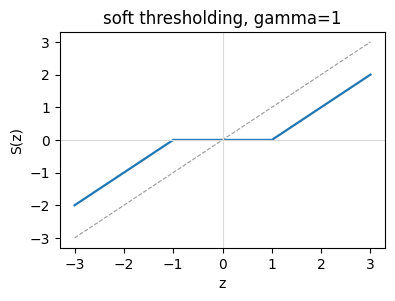

In [10]:
def soft_threshold(z, gamma):
    return np.sign(z)*np.maximum(np.abs(z)-gamma, 0.)

grid = np.linspace(-3, 3, 400)
plt.figure(figsize=(4.2, 2.8))
plt.plot(grid, soft_threshold(grid, 1.), lw=1.6)
plt.plot(grid, grid, ls='--', lw=.8, color='0.6')
plt.axhline(0, color='0.85', lw=.8); plt.axvline(0, color='0.85', lw=.8)
plt.title('soft thresholding, gamma=1'); plt.xlabel('z'); plt.ylabel('S(z)');

In [11]:
# High-dimensional sparse recovery: d=500 features, only 10 of them real.
gen = np.random.default_rng(7)
n_l, d_l, s_l = 200, 500, 10
Xl = gen.standard_normal((n_l, d_l))
theta_true = np.zeros(d_l)
support = gen.choice(d_l, s_l, replace=False)
theta_true[support] = gen.choice([-1., 1.], s_l)*gen.uniform(1.5, 3., s_l)
yl = Xl@theta_true + .5*gen.standard_normal(n_l)

def proximal_gradient(lmbda, steps=400):
    eta = 1/np.linalg.eigvalsh(Xl.T@Xl/n_l).max()
    th = np.zeros(d_l)
    for _ in range(steps):
        th = soft_threshold(th - eta*(Xl.T@(Xl@th-yl)/n_l), eta*lmbda)
    return th

theta_hat = proximal_gradient(.30)
found, truth = set(np.flatnonzero(theta_hat)), set(support)
print('nonzero coefficients:', len(found), 'of', d_l)
print('true features recovered:', len(truth & found), 'of', s_l)
print('false positives:', len(found - truth))

nonzero coefficients: 10 of 500
true features recovered: 10 of 10
false positives: 0


## PyTorch comparison

In [12]:
X_tensor = torch.tensor(X, dtype=torch.float64)
y_tensor = torch.tensor(y, dtype=torch.float64).reshape(-1,1)
model = torch.nn.Linear(2, 1, bias=False).double()
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)
for _ in range(300):
    optimizer.zero_grad()
    objective = .5*torch.mean((model(X_tensor)-y_tensor)**2)
    objective.backward()
    optimizer.step()
torch_theta = model.weight.detach().numpy().ravel()
print('PyTorch:     ', torch_theta.round(4))
print('from scratch:', theta_gd.round(4))
assert np.allclose(torch_theta, theta_gd, atol=1e-3)

PyTorch:      [ 1.4028 -0.8942]
from scratch: [ 1.4028 -0.8942]


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [13]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '05-gradient-sgd'
NOTES = COURSE / 'lectures' / 'figures'

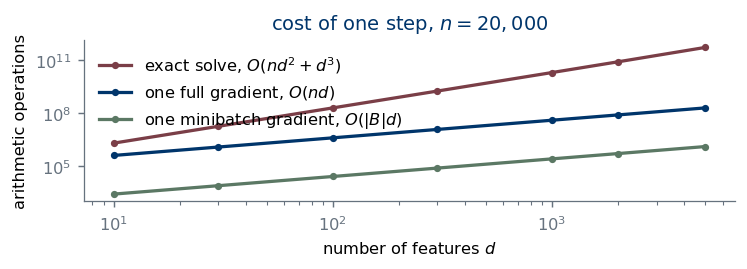

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/cost-scaling.pdf')

In [14]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np





SEED = 26510
rng = np.random.default_rng(SEED)

# Simulated design.  A real small data set cannot motivate this lecture: at
# n=200, d=2 the normal equations solve in under a millisecond.  Simulating
# lets us set both the size and, more usefully, the condition number exactly,
# so the conditioning and zig-zag figures illustrate a number we chose rather
# than whatever a particular data set happened to have.
SIM_N, SIM_D, SIM_KAPPA = 2000, 2, 8.0
SIM_THETA = np.array([1.4, -0.9])


def simulate(n, d, kappa, noise=0.5, seed=0):
    """Gaussian design whose Gram matrix has condition number ~kappa."""
    gen = np.random.default_rng(seed)
    # Eigenvalues spread geometrically from 1 down to 1/kappa.
    eigs = np.logspace(0, -np.log10(kappa), d)
    # A rotation mixes the axes so no single feature is the bad direction.
    angle = np.pi / 4
    rot = np.array([[np.cos(angle), -np.sin(angle)],
                    [np.sin(angle), np.cos(angle)]]) if d == 2 else np.linalg.qr(
        gen.standard_normal((d, d)))[0]
    root = rot @ np.diag(np.sqrt(eigs)) @ rot.T
    Xs = gen.standard_normal((n, d)) @ root
    theta = SIM_THETA if d == 2 else gen.standard_normal(d)
    ys = Xs @ theta + noise * gen.standard_normal(n)
    return Xs, ys


X, y = simulate(SIM_N, SIM_D, SIM_KAPPA, seed=SEED)
H = X.T @ X / len(X)
theta_star = np.linalg.solve(H, X.T @ y / len(X))


def objective(theta):
    residual = X @ theta - y
    return 0.5 * np.mean(residual ** 2)


def gradient(theta, indices=None):
    if indices is None:
        Xb, yb = X, y
    else:
        Xb, yb = X[indices], y[indices]
    return Xb.T @ (Xb @ theta - yb) / len(Xb)


def gd_path(start, eta, steps, batch_size=None, momentum=0.0):
    theta = np.asarray(start, dtype=float).copy()
    velocity = np.zeros_like(theta)
    points = [theta.copy()]
    losses = [objective(theta)]
    for _ in range(steps):
        if batch_size is None or batch_size >= len(X):
            g = gradient(theta)
        else:
            idx = rng.choice(len(X), batch_size, replace=False)
            g = gradient(theta, idx)
        velocity = momentum * velocity + g
        theta -= eta * velocity
        points.append(theta.copy())
        losses.append(objective(theta))
    return np.asarray(points), np.asarray(losses)


# Arithmetic cost of the exact solve against one gradient step, as d grows.
# This is the figure that motivates the lecture.  Operation counts are plotted
# rather than wall-clock: timings on a laptop are dominated by BLAS threading
# and come out non-monotone, which reads as noise rather than as the cubic-vs-
# linear separation that is the actual point.  A measured timing at d=2000 is
# quoted on the slide alongside.
import time as _time

_cost_n = 20_000
_cost_d = np.array([10, 30, 100, 300, 1000, 2000, 5000])
_exact = _cost_n * _cost_d ** 2 + _cost_d ** 3 / 3   # form X'X, then Cholesky
_grad = 2 * _cost_n * _cost_d                        # two matrix-vector passes
_mb = 2 * 128 * _cost_d                              # same, on 128 rows

fig, ax = plt.subplots(figsize=(FULL[0], 1.95))
ax.plot(_cost_d, _exact, "o-", color=RED, markersize=3,
        label="exact solve, $O(nd^2+d^3)$")
ax.plot(_cost_d, _grad, "o-", color=BLUE, markersize=3,
        label="one full gradient, $O(nd)$")
ax.plot(_cost_d, _mb, "o-", color=GREEN, markersize=3,
        label="one minibatch gradient, $O(|B|d)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set(xlabel="number of features $d$", ylabel="arithmetic operations",
       title=f"cost of one step, $n={_cost_n:,}$")
ax.legend(loc="upper left", framealpha=0)
fig.tight_layout(pad=0.3)
save(fig, OUT / "cost-scaling.pdf", OUT / "cost-scaling.svg")

measured at n=20000, d=2000 (ms): exact 5037, full grad 79.9, minibatch 0.12


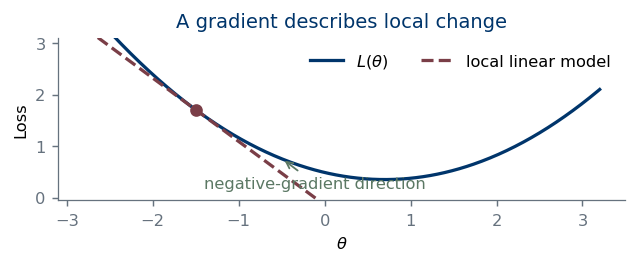

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/local-linearization.pdf')

In [15]:
# One measured point, best of several reps, to quote on the slide.
_d = 2000
_Xc = np.random.default_rng(1).standard_normal((_cost_n, _d))
_yc = np.random.default_rng(2).standard_normal(_cost_n)
_th = np.zeros(_d)


def _time_it(fn, reps=5):
    best = np.inf
    for _ in range(reps):
        t0 = _time.perf_counter(); fn(); best = min(best, _time.perf_counter() - t0)
    return best * 1000


print("measured at n=20000, d=2000 (ms): exact %.0f, full grad %.1f, minibatch %.2f" % (
    _time_it(lambda: np.linalg.solve(_Xc.T @ _Xc, _Xc.T @ _yc)),
    _time_it(lambda: _Xc.T @ (_Xc @ _th - _yc) / _cost_n),
    _time_it(lambda: _Xc[:128].T @ (_Xc[:128] @ _th - _yc[:128]) / 128)))


# One-dimensional local linear approximation.
grid_x = np.linspace(-2.8, 3.2, 500)
function = 0.28 * (grid_x - 0.7) ** 2 + 0.35
x0 = -1.5
y0 = 0.28 * (x0 - 0.7) ** 2 + 0.35
slope = 0.56 * (x0 - 0.7)
tangent = y0 + slope * (grid_x - x0)
fig, ax = plt.subplots(figsize=(FULL_SHORT[0], 1.62))
ax.plot(grid_x, function, color=BLUE, label="$L(\\theta)$")
ax.plot(grid_x, tangent, color=RED, linestyle="--", label="local linear model")
ax.scatter([x0], [y0], color=RED, zorder=4)
ax.annotate("negative-gradient direction", xy=(-0.5, 0.76), xytext=(-1.4, 0.18), arrowprops=dict(arrowstyle="->", color=GREEN), color=GREEN)
ax.set(xlabel="$\\theta$", ylabel="Loss", ylim=(-0.05, 3.1), title="A gradient describes local change")
ax.legend(ncol=2)
save(fig, OUT / "local-linearization.pdf", OUT / "local-linearization.svg")

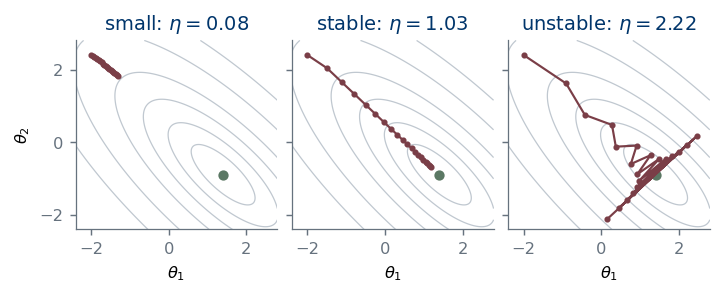

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/learning-rate-paths.pdf')

In [16]:
# Contours of the simulated least-squares objective and learning-rate paths.
t1, t2 = np.meshgrid(np.linspace(-2.4, 2.8, 260), np.linspace(-2.4, 2.8, 260))
surface = np.empty_like(t1)
for i in range(t1.shape[0]):
    theta_rows = np.column_stack([t1[i], t2[i]])
    residual = X @ theta_rows.T - y[:, None]
    surface[i] = 0.5 * np.mean(residual ** 2, axis=0)
lambda_max = np.linalg.eigvalsh(H).max()
etas = [0.08 / lambda_max, 1.0 / lambda_max, 2.15 / lambda_max]
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, eta, label in zip(axes, etas, ["small", "stable", "unstable"]):
    ax.contour(t1, t2, surface, levels=[0.2, 0.35, 0.6, 1.0, 1.8, 3.0], colors="#C0C8D0", linewidths=0.7)
    path, _ = gd_path([-2.0, 2.4], eta, 20)
    ax.plot(path[:, 0], path[:, 1], "o-", color=RED, markersize=2.4, linewidth=1.2)
    ax.scatter(theta_star[0], theta_star[1], color=GREEN, s=22)
    ax.set(title=f"{label}: $\\eta={eta:.2f}$", xlabel="$\\theta_1$")
axes[0].set_ylabel("$\\theta_2$")
fig.tight_layout(w_pad=0.5)
save(fig, OUT / "learning-rate-paths.pdf", OUT / "learning-rate-paths.svg")

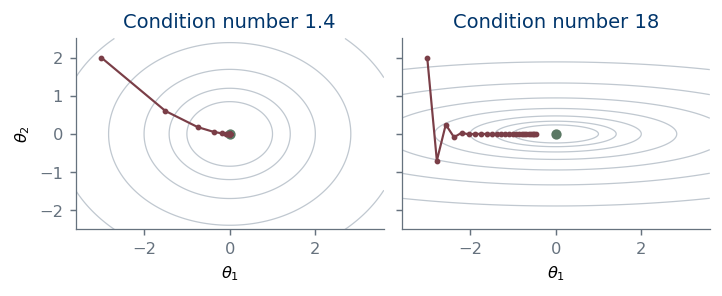

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/conditioning-paths.pdf')

In [17]:
# Conditioning on analytic quadratics.
def quadratic_path(A, start, eta, steps, momentum=0):
    point = np.asarray(start, dtype=float).copy()
    velocity = np.zeros(2)
    points = [point.copy()]
    for _ in range(steps):
        velocity = momentum * velocity + A @ point
        point -= eta * velocity
        points.append(point.copy())
    return np.asarray(points)


gx, gy = np.meshgrid(np.linspace(-3.6, 3.6, 280), np.linspace(-2.5, 2.5, 260))
grid = np.dstack([gx, gy])
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, A, eta, title in [
    (axes[0], np.diag([1, 1.4]), 0.5, "Condition number 1.4"),
    (axes[1], np.diag([1, 18]), 0.075, "Condition number 18"),
]:
    values = 0.5 * np.einsum("...i,ij,...j->...", grid, A, grid)
    ax.contour(gx, gy, values, levels=[0.5, 1, 2, 4, 8, 16, 32], colors="#C0C8D0", linewidths=0.7)
    path = quadratic_path(A, [-3, 2], eta, 24)
    ax.plot(path[:, 0], path[:, 1], "o-", color=RED, markersize=2.2, linewidth=1.2)
    ax.scatter([0], [0], color=GREEN, s=22)
    ax.set(title=title, xlabel="$\\theta_1$")
axes[0].set_ylabel("$\\theta_2$")
fig.tight_layout(w_pad=0.7)
save(fig, OUT / "conditioning-paths.pdf", OUT / "conditioning-paths.svg")

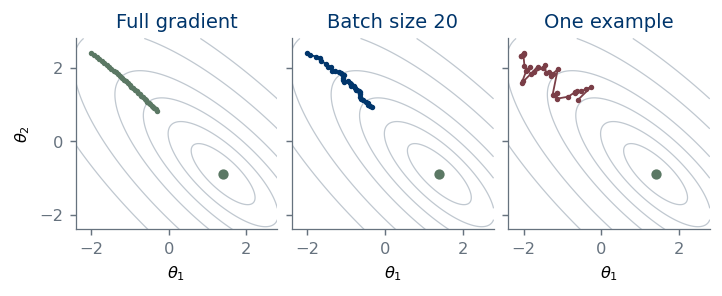

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/stochastic-paths.pdf')

In [18]:
# Stochastic paths on the simulated objective.
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, batch, label, color in [
    (axes[0], None, "Full gradient", GREEN),
    (axes[1], 20, "Batch size 20", BLUE),
    (axes[2], 1, "One example", RED),
]:
    ax.contour(t1, t2, surface, levels=[0.2, 0.35, 0.6, 1.0, 1.8, 3.0], colors="#C0C8D0", linewidths=0.7)
    path, _ = gd_path([-2.0, 2.4], 0.15, 35, batch_size=batch)
    ax.plot(path[:, 0], path[:, 1], "o-", color=color, markersize=2.0, linewidth=1.0)
    ax.scatter(theta_star[0], theta_star[1], color=GREEN, s=22)
    ax.set(title=label, xlabel="$\\theta_1$")
axes[0].set_ylabel("$\\theta_2$")
fig.tight_layout(w_pad=0.5)
save(fig, OUT / "stochastic-paths.pdf", OUT / "stochastic-paths.svg")

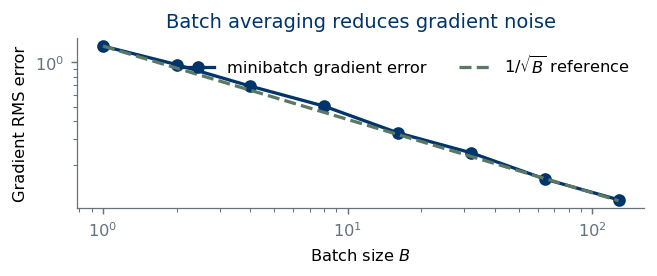

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/batch-noise.pdf')

In [19]:
# Empirical gradient error versus batch size at a fixed parameter.
batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64, 128])
theta_probe = np.array([-0.8, 1.2])
full_gradient = gradient(theta_probe)
rms = []
for batch in batch_sizes:
    estimates = np.array([gradient(theta_probe, rng.choice(len(X), batch, replace=False)) for _ in range(800)])
    rms.append(np.sqrt(np.mean(np.sum((estimates - full_gradient) ** 2, axis=1))))
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.loglog(batch_sizes, rms, "o-", color=BLUE, label="minibatch gradient error")
reference = rms[0] / np.sqrt(batch_sizes)
ax.loglog(batch_sizes, reference, linestyle="--", color=GREEN, label="$1/\\sqrt{B}$ reference")
ax.set(xlabel="Batch size $B$", ylabel="Gradient RMS error", title="Batch averaging reduces gradient noise")
ax.legend(ncol=2)
save(fig, OUT / "batch-noise.pdf", OUT / "batch-noise.svg")

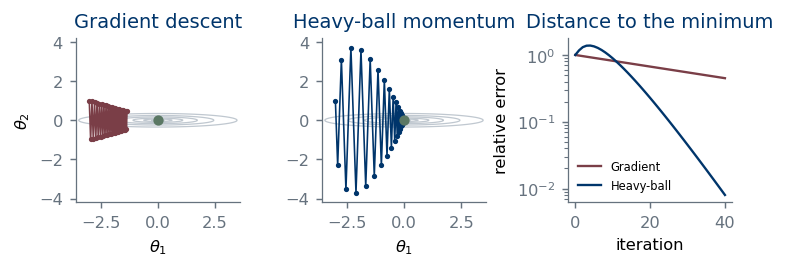

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/momentum-paths.pdf')

In [20]:
# Momentum on an ill-conditioned quadratic.
#
# Each method gets its own optimal constant parameters, otherwise the
# comparison is rigged.  The earlier version used one eta for both on a kappa=18
# problem, where gradient descent's slow multiplier (0.94) and heavy ball's
# (0.906) are nearly equal -- so momentum bought nothing and merely spiralled,
# which read as momentum being worse.  At kappa=100 with Polyak's parameters the
# rates are 0.980 against 0.818 per step, which is the sqrt(kappa) speedup.
A = np.diag([1.0, 100.0])
_M, _m = 100.0, 1.0
_kap = _M / _m
_eta_gd = 2 / (_M + _m)                                  # optimal GD step
_beta_hb = ((np.sqrt(_kap) - 1) / (np.sqrt(_kap) + 1)) ** 2
_eta_hb = 4 / (np.sqrt(_M) + np.sqrt(_m)) ** 2           # Polyak's parameters
_gxm, _gym = np.meshgrid(np.linspace(-3.6, 3.6, 280), np.linspace(-4.2, 4.2, 260))
_gridm = np.dstack([_gxm, _gym])
values = 0.5 * np.einsum("...i,ij,...j->...", _gridm, A, _gridm)
_STEPS = 40
_runs = [(0.0, _eta_gd, "Gradient descent", RED),
         (_beta_hb, _eta_hb, "Heavy-ball momentum", BLUE)]
fig, axes = plt.subplots(1, 3, figsize=(FULL[0], 1.95))
for ax, (beta, eta, title, color) in zip(axes[:2], _runs):
    ax.contour(_gxm, _gym, values, levels=[0.05, 0.2, 0.6, 1.5, 3.0, 6.0],
               colors="#C0C8D0", linewidths=0.7)
    path = quadratic_path(A, [-3, 1.0], eta, _STEPS, momentum=beta)
    ax.plot(path[:, 0], path[:, 1], "o-", color=color, markersize=1.9, linewidth=0.9)
    ax.scatter([0], [0], color=GREEN, s=22, zorder=5)
    ax.set(title=title, xlabel=r"$\theta_1$", ylim=(-4.2, 4.2))
axes[0].set_ylabel(r"$\theta_2$")
# The paths both oscillate; only the error decay separates them.
for beta, eta, title, color in _runs:
    path = quadratic_path(A, [-3, 1.0], eta, _STEPS, momentum=beta)
    err = np.linalg.norm(path, axis=1) / np.linalg.norm(path[0])
    axes[2].semilogy(np.arange(len(err)), err, color=color, linewidth=1.3, label=title.split()[0])
axes[2].set(xlabel="iteration", ylabel="relative error",
            title="Distance to the minimum")
axes[2].legend(fontsize=6.4, framealpha=0, loc="lower left")
fig.tight_layout(pad=0.3, w_pad=0.5)
save(fig, OUT / "momentum-paths.pdf", OUT / "momentum-paths.svg")

momentum figure: kappa=100, GD eta=0.0198, HB eta=0.0331 beta=0.669


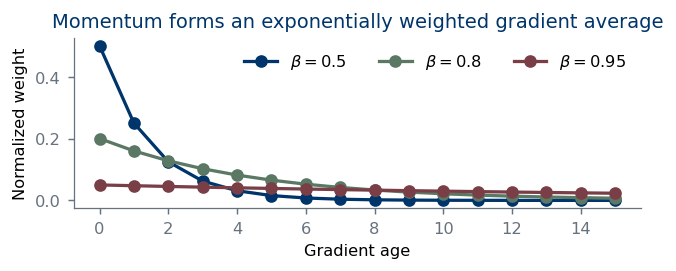

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/momentum-memory.pdf')

In [21]:
print(f"momentum figure: kappa={_kap:.0f}, GD eta={_eta_gd:.4f}, HB eta={_eta_hb:.4f} beta={_beta_hb:.3f}")


# Momentum memory weights.
ages = np.arange(16)
fig, ax = plt.subplots(figsize=FULL_SHORT)
for beta, color in [(0.5, BLUE), (0.8, GREEN), (0.95, RED)]:
    ax.plot(ages, (1 - beta) * beta ** ages, "o-", color=color, label=f"$\\beta={beta}$")
ax.set(xlabel="Gradient age", ylabel="Normalized weight", title="Momentum forms an exponentially weighted gradient average")
ax.legend(ncol=3)
save(fig, OUT / "momentum-memory.pdf", OUT / "momentum-memory.svg")

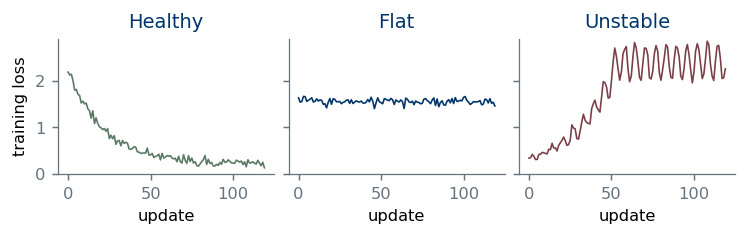

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/training-diagnostics.pdf')

In [22]:
# Diagnostic training curves.  Minibatch noise is the point: a real healthy
# curve is a noisy decay onto a plateau, not a clean exponential, and students
# who have only seen the smooth version read ordinary noise as a failure.
_dg = np.random.default_rng(4)
updates = np.arange(120)
fig, axes = plt.subplots(1, 3, figsize=FULL_SHORT, sharey=True)
_healthy = 2.0 * np.exp(-updates / 22) + 0.22 + 0.055 * _dg.standard_normal(len(updates))
axes[0].plot(updates, _healthy, color=GREEN, linewidth=0.9)
axes[0].set_title("Healthy")
_flat = 1.55 + 0.05 * _dg.standard_normal(len(updates))
axes[1].plot(updates, _flat, color=BLUE, linewidth=0.9)
axes[1].set_title("Flat")
_unstable = np.minimum(2.4, 0.30 * np.exp(updates / 26)) * (1 + 0.16 * np.sin(updates)) \
    + 0.05 * _dg.standard_normal(len(updates))
axes[2].plot(updates, _unstable, color=RED, linewidth=0.9)
axes[2].set_title("Unstable")
for ax in axes:
    ax.set(xlabel="update", ylim=(0, 2.9))
axes[0].set_ylabel("training loss")
fig.tight_layout(pad=0.3, w_pad=0.5)
save(fig, OUT / "training-diagnostics.pdf", OUT / "training-diagnostics.svg")

Simulated design: n=2000, d=2, target kappa=8.0
realized Gram condition number: 7.67
Hessian eigenvalues: [0.12612847 0.96683153]
Stable constant-step upper bound: 2.068613


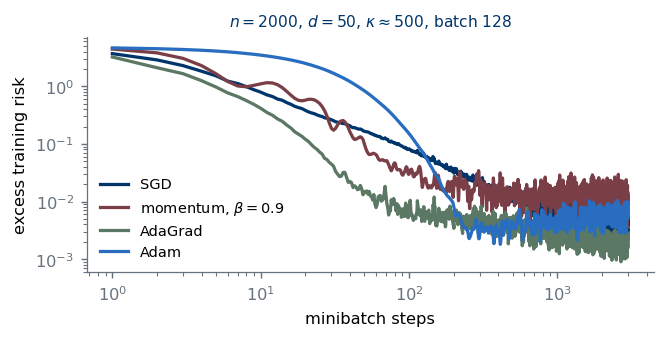

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/optimizer-comparison.pdf')

In [23]:
print(f"Simulated design: n={SIM_N}, d={SIM_D}, target kappa={SIM_KAPPA}")
print(f"realized Gram condition number: {np.linalg.cond(H):.2f}")
print(f"Hessian eigenvalues: {np.linalg.eigvalsh(H)}")
print(f"Stable constant-step upper bound: {2 / lambda_max:.6f}")


# ===========================================================================
#  Adaptive methods, the optimizer comparison, and the lasso
# ===========================================================================

def _illcond_problem(n=2000, d=50, kappa=500.0, seed=7):
    """Least squares whose Hessian has a prescribed condition number."""
    r = np.random.default_rng(seed)
    scales = np.geomspace(1.0, 1.0 / np.sqrt(kappa), d)
    X = r.normal(size=(n, d)) * scales
    beta = r.normal(size=d)
    y = X @ beta + 0.5 * r.normal(size=n)
    best, *_ = np.linalg.lstsq(X, y, rcond=None)
    floor = float(((y - X @ best) ** 2).mean())
    return X, y, floor


def _run(method, X, y, eta, steps, batch=128, beta1=0.9, beta2=0.999, eps=1e-8):
    """One optimizer, returning excess training risk per step."""
    n, d = X.shape
    r = np.random.default_rng(11)
    th = np.zeros(d)
    v = np.zeros(d)      # momentum / first moment
    s = np.zeros(d)      # accumulated squared gradient
    out = []
    best, *_ = np.linalg.lstsq(X, y, rcond=None)
    floor = float(((y - X @ best) ** 2).mean())
    for k in range(1, steps + 1):
        idx = r.integers(0, n, batch)
        Xb, yb = X[idx], y[idx]
        g = 2.0 / batch * Xb.T @ (Xb @ th - yb)
        if method == "sgd":
            th = th - eta * g
        elif method == "momentum":
            v = beta1 * v + g
            th = th - eta * v
        elif method == "adagrad":
            s = s + g * g
            th = th - eta * g / (np.sqrt(s) + eps)
        elif method == "adam":
            v = beta1 * v + (1 - beta1) * g
            s = beta2 * s + (1 - beta2) * g * g
            vh = v / (1 - beta1**k)
            sh = s / (1 - beta2**k)
            th = th - eta * vh / (np.sqrt(sh) + eps)
        out.append(max(((y - X @ th) ** 2).mean() - floor, 1e-10))
    return np.array(out)


def optimizer_comparison():
    """SGD, momentum, AdaGrad and Adam on the same ill-conditioned problem."""
    X, y, _ = _illcond_problem()
    lmax = np.linalg.eigvalsh(2.0 / len(y) * X.T @ X).max()
    base = 1.0 / lmax
    runs = [("sgd", 0.5 * base, BLUE, "SGD"),
            ("momentum", 0.15 * base, RED, r"momentum, $\beta=0.9$"),
            ("adagrad", 0.30, GREEN, "AdaGrad"),
            ("adam", 0.02, BLUE_BRIGHT, "Adam")]
    fig, ax = plt.subplots(figsize=FULL_TALL)
    for method, eta, colour, label in runs:
        curve = _run(method, X, y, eta, steps=3000)
        ax.loglog(np.arange(1, len(curve) + 1), curve, color=colour, lw=1.8, label=label)
    ax.set_xlabel("minibatch steps")
    ax.set_ylabel("excess training risk")
    ax.legend(loc="lower left", fontsize=8)
    ax.set_title(r"$n=2000$, $d=50$, $\kappa\approx500$, batch $128$", fontsize=8.6)
    return save(fig, OUT / "optimizer-comparison.pdf", OUT / "optimizer-comparison.svg")

optimizer_comparison()

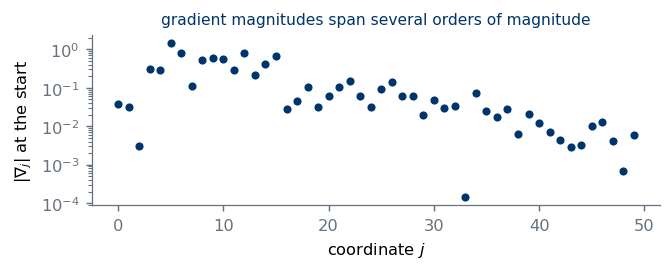

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/gradient-scales.pdf')

In [24]:
def gradient_scales():
    """Why a single learning rate cannot suit every coordinate."""
    X, y, _ = _illcond_problem()
    g = 2.0 / len(y) * X.T @ (X @ np.zeros(X.shape[1]) - y)
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.semilogy(np.abs(g), "o", ms=3.5, color=BLUE)
    ax.set_xlabel("coordinate $j$")
    ax.set_ylabel(r"$|\nabla_j|$ at the start")
    ax.set_title("gradient magnitudes span several orders of magnitude", fontsize=8.6)
    return save(fig, OUT / "gradient-scales.pdf", OUT / "gradient-scales.svg")

gradient_scales()

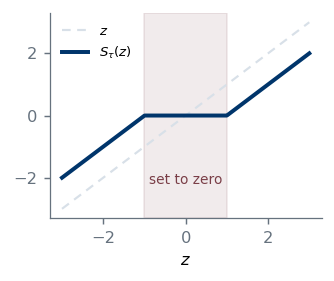

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/soft-threshold.pdf')

In [25]:
def soft_threshold_figure():
    """The soft-thresholding operator."""
    z = np.linspace(-3, 3, 600)
    t = 1.0
    st = np.sign(z) * np.maximum(np.abs(z) - t, 0.0)
    fig, ax = plt.subplots(figsize=(2.70, 2.05))
    ax.plot(z, z, color=RULE, lw=1.2, ls=(0, (4, 3)), label=r"$z$")
    ax.plot(z, st, color=BLUE, lw=2.2, label=r"$S_\tau(z)$")
    ax.axvspan(-t, t, color=RED, alpha=0.10)
    ax.annotate("set to zero", xy=(0, -2.2), ha="center", color=RED, fontsize=7.6)
    ax.set_xlabel("$z$")
    ax.legend(loc="upper left", fontsize=7.4)
    return save(fig, OUT / "soft-threshold.pdf", OUT / "soft-threshold.svg")

soft_threshold_figure()

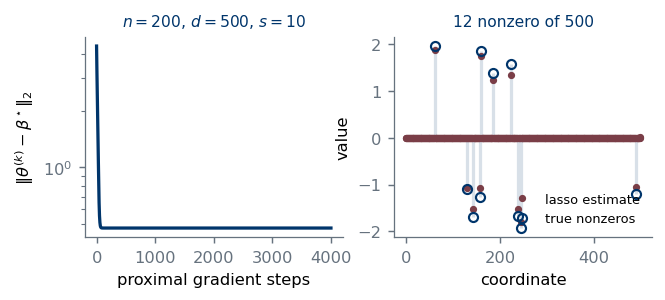

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/lasso-recovery.pdf')

In [26]:
def lasso_sparse_recovery():
    """High-dimensional sparse simulation: proximal gradient finds the support."""
    r = np.random.default_rng(3)
    n, d, s = 200, 500, 10
    X = r.normal(size=(n, d)) / np.sqrt(n)
    beta = np.zeros(d)
    support = r.choice(d, s, replace=False)
    beta[support] = r.choice([-1.0, 1.0], s) * r.uniform(1.0, 2.0, s)
    y = X @ beta + 0.05 * r.normal(size=n)

    lmax = np.linalg.eigvalsh(2.0 * X.T @ X).max()
    eta = 1.0 / lmax
    lam = 0.30
    th = np.zeros(d)
    err = []
    for _ in range(4000):
        g = 2.0 * X.T @ (X @ th - y)
        z = th - eta * g
        th = np.sign(z) * np.maximum(np.abs(z) - eta * lam, 0.0)
        err.append(np.linalg.norm(th - beta))

    fig, axes = plt.subplots(1, 2, figsize=FULL)
    ax = axes[0]
    ax.semilogy(err, color=BLUE, lw=1.8)
    ax.set_xlabel("proximal gradient steps")
    ax.set_ylabel(r"$\|\theta^{(k)}-\beta^\star\|_2$")
    ax.set_title(f"$n={n}$, $d={d}$, $s={s}$", fontsize=8.6)

    ax = axes[1]
    ax.stem(np.arange(d), beta, linefmt=RULE, markerfmt=" ", basefmt=" ")
    ax.plot(np.arange(d), th, "o", ms=3.0, color=RED, label="lasso estimate")
    ax.plot(support, beta[support], "o", ms=5.0, mfc="none", mec=BLUE, mew=1.2,
            label=r"true nonzeros")
    ax.set_xlabel("coordinate")
    ax.set_ylabel("value")
    ax.legend(loc="lower right", fontsize=7.2)
    nz = int((np.abs(th) > 1e-6).sum())
    ax.set_title(f"{nz} nonzero of {d}", fontsize=8.6)
    return save(fig, OUT / "lasso-recovery.pdf", OUT / "lasso-recovery.svg")

lasso_sparse_recovery()

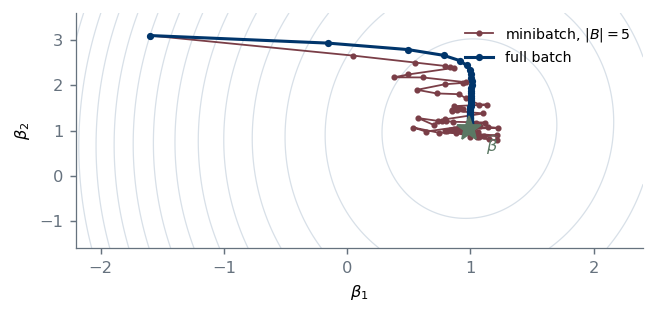

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/batch-vs-sgd-paths.pdf')

In [27]:
def batch_vs_sgd_paths():
    """Full-batch and minibatch paths over the same contours.

    A deliberately elongated two-parameter problem, so both effects are visible:
    the valley makes descent slow, and the minibatch gradient makes the path
    wander around the full-batch curve.
    """
    r = np.random.default_rng(5)
    n = 400
    Xp = r.normal(size=(n, 2)) * np.array([1.0, 0.34])   # kappa about 9
    bstar = np.array([1.0, 1.0])
    yp = Xp @ bstar + 0.6 * r.normal(size=n)
    best, *_ = np.linalg.lstsq(Xp, yp, rcond=None)

    def obj(t):
        return 0.5 * np.mean((Xp @ t - yp) ** 2)

    def step(t, idx, eta):
        Xb, yb = Xp[idx], yp[idx]
        return t - eta * (Xb.T @ (Xb @ t - yb) / len(yb))

    lmax = np.linalg.eigvalsh(Xp.T @ Xp / n).max()
    eta = 0.55 / lmax
    start = np.array([-1.6, 3.1])
    rr = np.random.default_rng(17)

    full = [start.copy()]
    t = start.copy()
    for _ in range(60):
        t = step(t, slice(None), eta)
        full.append(t.copy())
    full = np.array(full)

    mini = [start.copy()]
    t = start.copy()
    for _ in range(60):
        t = step(t, rr.integers(0, n, 5), eta)
        mini.append(t.copy())
    mini = np.array(mini)

    g1 = np.linspace(-2.2, 2.4, 200)
    g2 = np.linspace(-1.6, 3.6, 200)
    G1, G2 = np.meshgrid(g1, g2)
    Z = np.empty_like(G1)
    for i in range(G1.shape[0]):
        for j in range(G1.shape[1]):
            Z[i, j] = obj(np.array([G1[i, j], G2[i, j]]))

    fig, ax = plt.subplots(figsize=FULL_TALL)
    ax.contour(G1, G2, Z, levels=16, colors=RULE, linewidths=0.7)
    ax.plot(mini[:, 0], mini[:, 1], "-o", ms=2.4, lw=1.0, color=RED,
            label=r"minibatch, $|B|=5$")
    ax.plot(full[:, 0], full[:, 1], "-o", ms=3.0, lw=1.7, color=BLUE,
            label="full batch")
    ax.plot(*best, marker="*", ms=14, color=GREEN, zorder=5)
    ax.annotate(r"$\widehat\beta$", xy=best, xytext=(9, -13),
                textcoords="offset points", color=GREEN, fontsize=9)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.legend(loc="upper right", fontsize=7.8)
    return save(fig, OUT / "batch-vs-sgd-paths.pdf", OUT / "batch-vs-sgd-paths.svg")

batch_vs_sgd_paths()

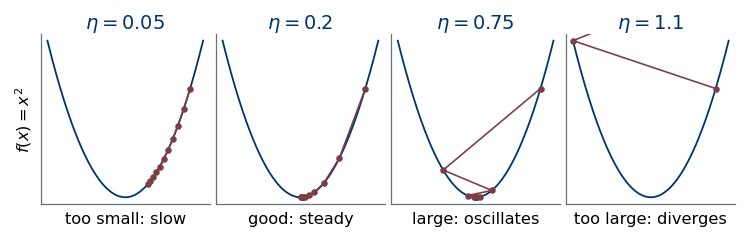

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/one-dim-learning-rates.pdf')

In [28]:
def one_dim_learning_rates():
    """Four learning-rate regimes on f(x)=x^2, following d2l chapter_optimization/gd.

    With f(x)=x^2 the curvature is a=2, so the exact thresholds are eta<=1/a=0.5
    for monotone motion, 0.5<eta<1 for convergent oscillation, and eta>1/a*2=1
    for divergence.  The four rates below sit one in each regime, which is the
    point of the figure: the slide states those thresholds and this shows them.
    """
    f = lambda x: x ** 2
    settings = [
        (0.05, "too small: slow"),
        (0.20, "good: steady"),
        (0.75, "large: oscillates"),
        (1.10, "too large: diverges"),
    ]
    grid = np.linspace(-12, 12, 400)
    fig, axes = plt.subplots(1, 4, figsize=(FULL[0], 1.72), sharex=True, sharey=True)
    for ax, (eta, label) in zip(axes, settings):
        x, xs = 10.0, [10.0]
        for _ in range(10):
            x = x - eta * 2 * x
            xs.append(x)
        xs = np.array(xs)
        ax.plot(grid, f(grid), color=BLUE, linewidth=1.0)
        ax.plot(xs, f(xs), "o-", color=RED, markersize=2.6, linewidth=0.9)
        ax.set_title(f"$\\eta={eta}$", pad=3)
        ax.set_xlabel(label)
        ax.set_ylim(-6, 150)
        ax.set_xlim(-13, 13)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].set_ylabel("$f(x)=x^2$")
    fig.tight_layout(pad=0.3, w_pad=0.4)
    return save(fig, OUT / "one-dim-learning-rates.pdf",
                OUT / "one-dim-learning-rates.svg")

one_dim_learning_rates()

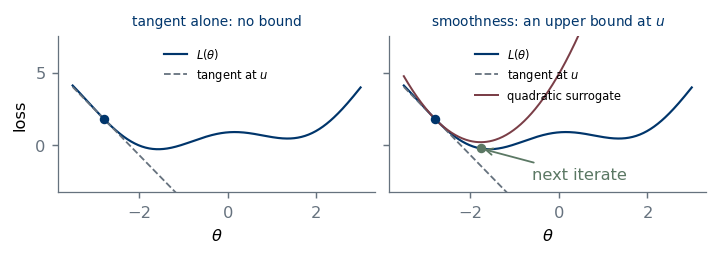

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/quadratic-upper-bound.pdf')

In [29]:
def quadratic_upper_bound():
    """Smoothness makes a quadratic a local upper bound on a general loss.

    Left: the tangent line only touches, and L runs away from it.  Right: adding
    (M/2)||v-u||^2 lifts the tangent into a surrogate that sits above L
    everywhere and touches at u; minimizing the surrogate is the gradient step
    with eta=1/M, which is why the same 2/M threshold appears for general L.
    """
    L = lambda x: 0.35 * x ** 2 + 0.9 * np.cos(1.6 * x) + 0.25 * x
    dL = lambda x: 0.7 * x - 1.44 * np.sin(1.6 * x) + 0.25
    M = 0.7 + 1.44 * 1.6                     # sup |L''| on the plotted range
    u = -2.8
    grid = np.linspace(-3.5, 3.0, 400)
    tangent = L(u) + dL(u) * (grid - u)
    surrogate = tangent + 0.5 * M * (grid - u) ** 2
    step = u - dL(u) / M

    fig, axes = plt.subplots(1, 2, figsize=(FULL[0], 1.85), sharey=True)
    for ax, show in zip(axes, [False, True]):
        ax.plot(grid, L(grid), color=BLUE, linewidth=1.2, label="$L(\\theta)$")
        ax.plot(grid, tangent, color=MUTED, linestyle="--", linewidth=1.0,
                label="tangent at $u$")
        if show:
            ax.plot(grid, surrogate, color=RED, linewidth=1.1,
                    label="quadratic surrogate")
            ax.scatter([step], [L(step)], color=GREEN, s=18, zorder=5)
            ax.annotate("next iterate", xy=(step, L(step)), xytext=(step + 1.15, L(step) - 2.1),
                        arrowprops=dict(arrowstyle="->", color=GREEN), color=GREEN)
        ax.scatter([u], [L(u)], color=BLUE, s=18, zorder=5)
        ax.set_xlabel("$\\theta$")
        ax.set_ylim(-3.2, 7.5)
        ax.legend(loc="upper center", fontsize=6.4, framealpha=0)
    axes[0].set_ylabel("loss")
    axes[0].set_title("tangent alone: no bound", fontsize=7.6)
    axes[1].set_title("smoothness: an upper bound at $u$", fontsize=7.6)
    fig.tight_layout(pad=0.3, w_pad=0.5)
    return save(fig, OUT / "quadratic-upper-bound.pdf",
                OUT / "quadratic-upper-bound.svg")

quadratic_upper_bound()

zigzag: steep coord sign changes 60 times in 60 steps; flat coord monotone: True


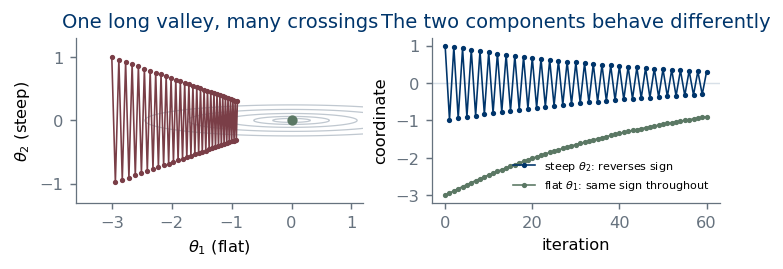

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/05-gradient-sgd/zigzag-components.pdf')

In [30]:
def zigzag_components():
    """The two components of the gradient sequence in an ill-conditioned valley.

    This is the figure that motivates momentum.  The claim on the slide is that
    the steep coordinate keeps reversing sign while the flat one persists; the
    right panel shows exactly that, which is what makes averaging recent
    gradients cancel one and accumulate the other.
    """
    Az = np.diag([1.0, 100.0])
    eta = 2 / (100.0 + 1.0)                 # optimal constant step for GD
    steps = 60
    path = quadratic_path(Az, [-3.0, 1.0], eta, steps)

    gx2, gy2 = np.meshgrid(np.linspace(-3.6, 1.2, 260), np.linspace(-1.3, 1.3, 240))
    grid2 = np.dstack([gx2, gy2])
    vals = 0.5 * np.einsum("...i,ij,...j->...", grid2, Az, grid2)

    fig, axes = plt.subplots(1, 2, figsize=(FULL[0], 1.95))
    axes[0].contour(gx2, gy2, vals, levels=[0.05, 0.2, 0.6, 1.5, 3.0],
                    colors="#C0C8D0", linewidths=0.7)
    axes[0].plot(path[:, 0], path[:, 1], "o-", color=RED, markersize=1.9, linewidth=0.9)
    axes[0].scatter([0], [0], color=GREEN, s=22, zorder=5)
    axes[0].set(xlabel=r"$\theta_1$ (flat)", ylabel=r"$\theta_2$ (steep)",
                title="One long valley, many crossings")

    it = np.arange(len(path))
    axes[1].axhline(0, color=RULE, linewidth=0.8)
    axes[1].plot(it, path[:, 1], "o-", color=BLUE, markersize=1.9, linewidth=0.9,
                 label=r"steep $\theta_2$: reverses sign")
    axes[1].plot(it, path[:, 0], "o-", color=GREEN, markersize=1.9, linewidth=0.9,
                 label=r"flat $\theta_1$: same sign throughout")
    axes[1].set(xlabel="iteration", ylabel="coordinate",
                title="The two components behave differently")
    axes[1].legend(fontsize=6.2, framealpha=0, loc="lower right")
    fig.tight_layout(pad=0.3, w_pad=0.6)
    sign_flips = int(np.sum(np.diff(np.sign(path[:, 1])) != 0))
    print(f"zigzag: steep coord sign changes {sign_flips} times in {steps} steps; "
          f"flat coord monotone: {bool(np.all(np.diff(path[:, 0]) > 0))}")
    return save(fig, OUT / "zigzag-components.pdf", OUT / "zigzag-components.svg")

zigzag_components()